# Tutorial 3: Benchmarks and comparison with SHAP / captum

Two evaluations that complement each other:

**Part A (sections 1–10):** Wall-clock time and peak memory for `shapiq.vision.ImageImputer` vs. the legacy `shapiq_games.benchmark.ImageClassifier` on ResNet-18 and ViT-B/16. On these runs the new code keeps up with (or beats) the hand-written baselines.

**Part B (section 11):** Same ResNet-18 image and 14-superpixel partition as `shap.PartitionExplainer` and `captum.ShapleyValueSampling`. We log runtime, Spearman agreement on superpixel scores, and how many lines it takes to get a heatmap.

**Why shapiq for this workflow:**
- Works with any Python callable (PyTorch, JAX/Flax, etc.).
- Higher-order interactions (k-SII, STII, FSII). SHAP and captum are first-order only.
- Batched coalition evaluation pays off when the budget is large.


In [1]:
from __future__ import annotations

import gc
import time
import tracemalloc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", DEVICE)
print("PyTorch version:", torch.__version__)

PyTorch device: cpu
PyTorch version: 2.10.0


## 1  Test image

We use the dog photo bundled with the `shapiq.vision` package so no network access is required.

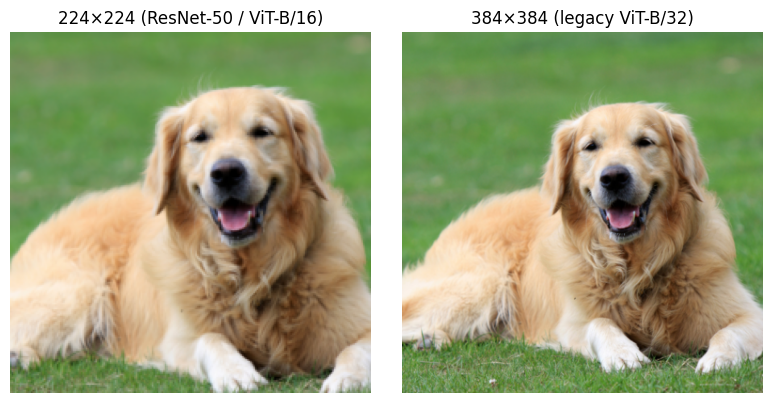

In [2]:
from torchvision import transforms

import shapiq.vision as _vision_module

# Dog photo ships with the package (no download)
DOG_PATH = Path(_vision_module.__file__).parent / "dog.png"
assert DOG_PATH.exists(), f"dog.png not found at {DOG_PATH}"

pil_224 = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
    ]
)(Image.open(DOG_PATH).convert("RGB"))

pil_384 = transforms.Compose(
    [
        transforms.Resize(384),
        transforms.CenterCrop(384),
    ]
)(Image.open(DOG_PATH).convert("RGB"))

image_224 = np.array(pil_224)
image_384 = np.array(pil_384)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_224)
axes[0].set_title("224×224 (ResNet-50 / ViT-B/16)")
axes[0].axis("off")
axes[1].imshow(image_384)
axes[1].set_title("384×384 (legacy ViT-B/32)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 2  Measurement utilities

- `measure_time_and_memory(fn, n_warmup)`: run `fn()` once and return `(wall_seconds, peak_python_bytes, peak_gpu_bytes)`.
- `random_coalitions(n_players, n_coalitions)`: reproducible boolean coalition matrix.


In [3]:
def measure_time_and_memory(
    fn,
    *,
    n_warmup: int = 0,
) -> dict:
    """Run fn(), return wall time and peak allocations.

    Args:
        fn: Zero-argument callable to benchmark.
        n_warmup: Number of un-timed warm-up calls before the measured call.

    Returns:
        dict with keys ``wall_s``, ``python_peak_mb``, ``gpu_peak_mb``.
    """
    for _ in range(n_warmup):
        fn()

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    tracemalloc.start()
    t0 = time.perf_counter()
    fn()
    t1 = time.perf_counter()
    _, python_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    gpu_peak_bytes = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0

    return {
        "wall_s": t1 - t0,
        "python_peak_mb": python_peak / 1024**2,
        "gpu_peak_mb": gpu_peak_bytes / 1024**2,
    }


def random_coalitions(n_players: int, n_coalitions: int, seed: int = SEED) -> np.ndarray:
    """Return a reproducible boolean coalition matrix of shape (n_coalitions, n_players)."""
    rng = np.random.default_rng(seed)
    return rng.integers(0, 2, size=(n_coalitions, n_players), dtype=bool)


print("Utilities defined.")

Utilities defined.


## 3  Load models

All models are loaded once and reused across benchmark runs.

In [4]:
# ResNet-18  (legacy-compatible)
from torchvision import models as tv_models

rn18_weights = tv_models.ResNet18_Weights.DEFAULT
rn18_preprocess = rn18_weights.transforms()  # expects (C, H, W) tensor → normalised
rn18 = tv_models.resnet18(weights=rn18_weights).eval().to(DEVICE)
print("ResNet-18 loaded:", sum(p.numel() for p in rn18.parameters()), "params")

# ResNet-50  (new imputer demo)
rn50_weights = tv_models.ResNet50_Weights.DEFAULT
rn50_preprocess = rn50_weights.transforms()
rn50 = tv_models.resnet50(weights=rn50_weights).eval().to(DEVICE)
print("ResNet-50 loaded:", sum(p.numel() for p in rn50.parameters()), "params")

ResNet-18 loaded: 11689512 params
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/alex/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:11<00:00, 9.19MB/s]


ResNet-50 loaded: 25557032 params


In [5]:
# ViT-B/16-224  (new imputer)
from transformers import ViTForImageClassification, ViTImageProcessor

VIT_B16_CKPT = "google/vit-base-patch16-224"
vit_b16_processor = ViTImageProcessor.from_pretrained(VIT_B16_CKPT)
vit_b16_model = ViTForImageClassification.from_pretrained(VIT_B16_CKPT).eval().to(DEVICE)
print("ViT-B/16 loaded:", sum(p.numel() for p in vit_b16_model.parameters()), "params")

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT-B/16 loaded: 86567656 params


In [9]:
# ViT-B/32-384  (legacy game model)
VIT_B32_CKPT = "google/vit-base-patch32-384"
vit_b32_processor = ViTImageProcessor.from_pretrained(VIT_B32_CKPT)
vit_b32_model = ViTForImageClassification.from_pretrained(VIT_B32_CKPT).eval().to(DEVICE)
print("ViT-B/32-384 loaded:", sum(p.numel() for p in vit_b32_model.parameters()), "params")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT-B/32-384 loaded: 88297192 params


## 4  ResNet benchmark: legacy vs. new

**Legacy (`ResNetModel`):** Gray background `[127,127,127]`, SLIC superpixels, batched CPU tensors. Wrapped in `ImageClassifier(model_name="resnet_18")`.

**New (`ResNetArchitecture`):** Mean-color masking, SLIC superpixels, batched numpy plus model calls. Any CNN checkpoint you pass in.

The callables below match the interface `value_function` expects on both sides.


In [ ]:
def detect_class_id(model, preprocess, image: np.ndarray) -> int:
    """Return the argmax class id for a single image."""
    to_tensor = transforms.ToTensor()
    tensor = to_tensor(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(preprocess(tensor))
    return int(logits.argmax(-1).item())


def make_resnet_callable(model, preprocess, class_id: int):
    """Return a callable (N, H, W, C) uint8 numpy → (N,) class prob array.

    Accepts a single image (H, W, C) or a batch (N, H, W, C).
    Uses a fixed class_id. Call detect_class_id() first.
    """
    to_tensor = transforms.ToTensor()

    def _call(images: np.ndarray) -> np.ndarray:
        # Accept single image (H, W, C) or batch (N, H, W, C)
        if images.ndim == 3:
            images = images[np.newaxis]
        # Convert each (H, W, C) uint8 array → (C, H, W) float tensor
        tensors = torch.stack([to_tensor(img) for img in images]).to(DEVICE)
        tensors = preprocess(tensors)
        with torch.no_grad():
            logits = model(tensors)
            probs = F.softmax(logits, dim=-1)
        return probs[:, class_id].cpu().numpy()

    return _call

In [11]:
from shapiq.vision import ResNetArchitecture
from shapiq.vision.imputer import ImageImputer
from shapiq.vision.masking import MeanColorMasking
from shapiq.vision.players import SuperpixelStrategy

# Detect predicted class for each model
rn18_class_id = detect_class_id(rn18, rn18_preprocess, image_224)
rn18_callable = make_resnet_callable(rn18, rn18_preprocess, class_id=rn18_class_id)
print(f"ResNet-18 predicted class id: {rn18_class_id}")

rn50_class_id = detect_class_id(rn50, rn50_preprocess, image_224)
rn50_callable = make_resnet_callable(rn50, rn50_preprocess, class_id=rn50_class_id)
print(f"ResNet-50 predicted class id: {rn50_class_id}")

ResNet-18 predicted class id: 207
ResNet-50 predicted class id: 207


In [12]:
# Legacy ResNetModel  (gray background, ResNet-18)
from shapiq_games.benchmark._setup._resnet_setup import ResNetModel

LEGACY_N_SP = 14
legacy_resnet_model = ResNetModel(
    input_image=pil_224,
    n_superpixels=LEGACY_N_SP,
    verbose=False,
    batch_size=50,
)
print(
    f"Legacy ResNet-18 class id: {legacy_resnet_model.class_id}, "
    f"n_superpixels: {legacy_resnet_model.n_superpixels}"
)

/var/folders/6j/hm317l754974fpdzkx86fl140000gp/T/ipykernel_81837/2962982285.py:2: DeprecationWarning: This collection of games is deprecated and will be removed in a future version.
  from shapiq_games.benchmark._setup._resnet_setup import ResNetModel


Legacy ResNet-18 class id: 207, n_superpixels: 14


In [7]:
# Sweep parameters
BUDGETS = [50, 100, 200, 500]
N_SP_LIST = [9, 14, 25]
BATCH_SIZE = 50

resnet_rows = []

for n_sp in N_SP_LIST:
    # New ResNet-18 (mean-color)
    arch_rn18 = ResNetArchitecture(rn18_callable, masking_strategy=MeanColorMasking())
    imputer_rn18 = ImageImputer(
        arch_rn18,
        image_224,
        player_strategy=SuperpixelStrategy(n_segments=n_sp),
        normalize=False,
        batch_size=BATCH_SIZE,
    )
    actual_n_sp_rn18 = imputer_rn18._player_strategy.n_players

    # New ResNet-50 (mean-color)
    arch_rn50 = ResNetArchitecture(rn50_callable, masking_strategy=MeanColorMasking())
    imputer_rn50 = ImageImputer(
        arch_rn50,
        image_224,
        player_strategy=SuperpixelStrategy(n_segments=n_sp),
        normalize=False,
        batch_size=BATCH_SIZE,
    )
    actual_n_sp_rn50 = imputer_rn50._player_strategy.n_players

    for budget in BUDGETS:
        coalitions_rn18 = random_coalitions(actual_n_sp_rn18, budget)
        coalitions_rn50 = random_coalitions(actual_n_sp_rn50, budget)

        # new ResNet-18
        m = measure_time_and_memory(lambda c=coalitions_rn18: imputer_rn18.value_function(c))
        resnet_rows.append(
            {
                "impl": "new/ResNet-18",
                "n_players": actual_n_sp_rn18,
                "budget": budget,
                **m,
            }
        )

        # new ResNet-50
        m = measure_time_and_memory(lambda c=coalitions_rn50: imputer_rn50.value_function(c))
        resnet_rows.append(
            {
                "impl": "new/ResNet-50",
                "n_players": actual_n_sp_rn50,
                "budget": budget,
                **m,
            }
        )

        # legacy ResNet-18 (gray), only when n_sp == LEGACY_N_SP
        if n_sp == LEGACY_N_SP:
            coalitions_legacy = random_coalitions(legacy_resnet_model.n_superpixels, budget)
            m = measure_time_and_memory(lambda c=coalitions_legacy: legacy_resnet_model(c))
            resnet_rows.append(
                {
                    "impl": "legacy/ResNet-18",
                    "n_players": legacy_resnet_model.n_superpixels,
                    "budget": budget,
                    **m,
                }
            )

df_resnet = pd.DataFrame(resnet_rows)
print(df_resnet.to_string(index=False))

## 5  ViT benchmark: legacy vs. new

**Legacy (`ViTModel`):** ViT-B/32 at 384px. **One coalition per forward pass.** Hard-coded norm constants and manual submodule hooks.

**New (`ViTArchitecture`):** ViT-B/16 at 224px. All coalitions in one forward (chunked by `batch_size`), standard HuggingFace `forward`.


In [ ]:
from shapiq_games.benchmark._setup._vit_setup import ViTModel

# Legacy ViT: 16 macro-patch players on the 12×12 patch-32 grid
LEGACY_VIT_N_PLAYERS = 16
legacy_vit_model = ViTModel(
    n_patches=LEGACY_VIT_N_PLAYERS,
    input_image=pil_384,
    verbose=False,
)
print(f"Legacy ViT-B/32-384: {LEGACY_VIT_N_PLAYERS} players, class_id={legacy_vit_model.class_id}")

In [ ]:
from shapiq.vision import ViTArchitecture
from shapiq.vision.players import PatchStrategy

# ViT-B/16 grid: 224 / 16 = 14 tokens per side → 14×14 = 196 tokens total
VIT_B16_GRID = vit_b16_model.config.image_size // vit_b16_model.config.patch_size  # = 14
print(f"ViT-B/16 token grid: {VIT_B16_GRID}×{VIT_B16_GRID}")

VIT_PLAYER_COUNTS = [9, 16, 36]  # must be perfect squares

vit_rows = []

for n_players in VIT_PLAYER_COUNTS:
    # new ViT-B/16
    # Default ViT masking (MaskTokenStrategy). On HF ViT-B/16 this matches BoolMaskedPosStrategy
    arch_vit = ViTArchitecture(model=vit_b16_model, processor=vit_b16_processor)
    imputer_vit = ImageImputer(
        arch_vit,
        image_224,
        player_strategy=PatchStrategy(grid_size=VIT_B16_GRID, n_players=n_players),
        normalize=False,
        batch_size=BATCH_SIZE,
    )

    for budget in BUDGETS:
        coalitions = random_coalitions(n_players, budget)

        m = measure_time_and_memory(lambda c=coalitions: imputer_vit.value_function(c))
        vit_rows.append(
            {
                "impl": "new/ViT-B/16",
                "n_players": n_players,
                "budget": budget,
                **m,
            }
        )

        # legacy ViT-B/32-384 (n_players=16 only, per available legacy options)
        if n_players == LEGACY_VIT_N_PLAYERS:
            coalitions_legacy = random_coalitions(LEGACY_VIT_N_PLAYERS, budget)
            m = measure_time_and_memory(lambda c=coalitions_legacy: legacy_vit_model(c))
            vit_rows.append(
                {
                    "impl": "legacy/ViT-B/32-384",
                    "n_players": LEGACY_VIT_N_PLAYERS,
                    "budget": budget,
                    **m,
                }
            )

df_vit = pd.DataFrame(vit_rows)
print(df_vit.to_string(index=False))

## 6  Results: summary tables

In [ ]:
def format_table(df: pd.DataFrame, label: str) -> None:
    pivot = df.pivot_table(
        index=["impl", "n_players"],
        columns="budget",
        values=["wall_s", "python_peak_mb"],
        aggfunc="mean",
    ).round(3)
    print(f"\n{'=' * 72}")
    print(f"  {label}")
    print(f"{'=' * 72}")
    print(pivot.to_string())


format_table(df_resnet, "ResNet: wall-clock (s) and Python peak memory (MB)")
format_table(df_vit, "ViT: wall-clock (s) and Python peak memory (MB)")

## 7  Speed-up factor at matching player count & budget

Compute the speed-up of the new implementation relative to the legacy game.

In [ ]:
def speedup_table(df: pd.DataFrame, new_impl: str, legacy_impl: str) -> pd.DataFrame:
    new_df = df[df["impl"] == new_impl][["n_players", "budget", "wall_s"]]
    leg_df = df[df["impl"] == legacy_impl][["n_players", "budget", "wall_s"]]
    merged = new_df.merge(leg_df, on=["n_players", "budget"], suffixes=("_new", "_legacy"))
    merged["speedup"] = (merged["wall_s_legacy"] / merged["wall_s_new"]).round(2)
    return merged[["n_players", "budget", "wall_s_new", "wall_s_legacy", "speedup"]]


print("\nResNet speed-up (new ResNet-18 mean-color vs legacy ResNet-18 gray):")
sp_rn = speedup_table(df_resnet, "new/ResNet-18", "legacy/ResNet-18")
print(sp_rn.to_string(index=False))

print("\nViT speed-up (new ViT-B/16 vs legacy ViT-B/32-384, n_players=16):")
sp_vit = speedup_table(df_vit, "new/ViT-B/16", "legacy/ViT-B/32-384")
print(sp_vit.to_string(index=False))

## 8  Plots

In [ ]:
MARKERS: dict[str, str] = {
    "new/ResNet-18": "o",
    "new/ResNet-50": "s",
    "legacy/ResNet-18": "^",
    "new/ViT-B/16": "o",
    "legacy/ViT-B/32-384": "^",
}
COLORS: dict[str, str] = {
    "new/ResNet-18": "steelblue",
    "new/ResNet-50": "seagreen",
    "legacy/ResNet-18": "tomato",
    "new/ViT-B/16": "steelblue",
    "legacy/ViT-B/32-384": "tomato",
}
LINE_STYLES: dict[str, str] = {
    "new/ResNet-18": "-",
    "new/ResNet-50": "-",
    "legacy/ResNet-18": "--",
    "new/ViT-B/16": "-",
    "legacy/ViT-B/32-384": "--",
}


def plot_benchmark(df: pd.DataFrame, title: str, subset_impls=None, fixed_n_players=None) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    metrics = [("wall_s", "Wall-clock time (s)"), ("python_peak_mb", "Python peak memory (MB)")]

    sub = df.copy()
    if subset_impls:
        sub = sub[sub["impl"].isin(subset_impls)]
    if fixed_n_players:
        sub = sub[sub["n_players"] == fixed_n_players]

    for ax, (metric, ylabel) in zip(axes, metrics, strict=False):
        for impl, grp in sub.groupby("impl"):
            impl_s = str(impl)
            mean = grp.groupby("budget")[metric].mean()
            marker = MARKERS[impl_s] if impl_s in MARKERS else "o"
            color = COLORS[impl_s] if impl_s in COLORS else "gray"
            linestyle = LINE_STYLES[impl_s] if impl_s in LINE_STYLES else "-"
            ax.plot(
                mean.index,
                mean.values,
                marker=marker,
                color=color,
                linestyle=linestyle,
                label=impl_s,
            )
        ax.set_xlabel("Coalition budget", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(f"{title}\n{ylabel}", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_benchmark(
    df_resnet,
    "ResNet: new vs. legacy (14 superpixels)",
    subset_impls=["new/ResNet-18", "new/ResNet-50", "legacy/ResNet-18"],
    fixed_n_players=LEGACY_N_SP,
)

plot_benchmark(
    df_vit,
    "ViT: new vs. legacy (16 players)",
    subset_impls=["new/ViT-B/16", "legacy/ViT-B/32-384"],
    fixed_n_players=LEGACY_VIT_N_PLAYERS,
)

In [ ]:
# Grid-size sweep (new imputer only)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for col_idx, (df, title, impl_key) in enumerate(
    [
        (df_resnet, "ResNet: varying superpixel count", "new/ResNet-50"),
        (df_vit, "ViT-B/16: varying macro-patch count", "new/ViT-B/16"),
    ]
):
    ax = axes[col_idx]
    sub = df[df["impl"] == impl_key]
    cmap = plt.get_cmap("Blues")
    palette = cmap(np.linspace(0.4, 0.9, sub["n_players"].nunique()))
    for color, (n_pl, grp) in zip(palette, sub.groupby("n_players"), strict=False):
        mean = grp.groupby("budget")["wall_s"].mean()
        ax.plot(mean.index, mean.values, marker="o", color=color, label=f"{n_pl} players")
    ax.set_xlabel("Coalition budget", fontsize=12)
    ax.set_ylabel("Wall-clock time (s)", fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(title="# players", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9  Key observations

The cell below prints a brief narrative summary derived from the measured data.

In [ ]:
# Pull headline numbers for the 500-coalition run at the comparison player count
BUDGET_HL = 500


def headline(df, impl, n_pl, budget=BUDGET_HL, metric="wall_s"):
    row = df[(df["impl"] == impl) & (df["n_players"] == n_pl) & (df["budget"] == budget)]
    return float(row[metric].mean()) if len(row) else float("nan")


# ResNet
t_new_rn18 = headline(df_resnet, "new/ResNet-18", LEGACY_N_SP)
t_new_rn50 = headline(df_resnet, "new/ResNet-50", LEGACY_N_SP)
t_leg_rn = headline(df_resnet, "legacy/ResNet-18", LEGACY_N_SP)

# ViT
t_new_vit = headline(df_vit, "new/ViT-B/16", LEGACY_VIT_N_PLAYERS)
t_leg_vit = headline(df_vit, "legacy/ViT-B/32-384", LEGACY_VIT_N_PLAYERS)

print("=" * 72)
print(f"BENCHMARK SUMMARY  ({BUDGET_HL} coalitions, batch_size={BATCH_SIZE})")
print("=" * 72)

print(f"\nResNet ({LEGACY_N_SP} superpixels):")
print(f"  Legacy ResNet-18 (gray):     {t_leg_rn:.3f} s")
print(
    f"  New    ResNet-18 (mean-col): {t_new_rn18:.3f} s  "
    f"({'%.1f' % (t_leg_rn / t_new_rn18)}× speed-up vs legacy)"
)
print(f"  New    ResNet-50 (mean-col): {t_new_rn50:.3f} s")

print(f"\nViT ({LEGACY_VIT_N_PLAYERS} players):")
print(f"  Legacy ViT-B/32-384 (seq.): {t_leg_vit:.3f} s")
print(
    f"  New    ViT-B/16 (batched):  {t_new_vit:.3f} s  "
    f"({'%.1f' % (t_leg_vit / t_new_vit)}× speed-up vs legacy)"
)

print(
    "\nNote: new ViT-B/16 and legacy ViT-B/32-384 use different model weights "
    "and resolutions. The speed-up is throughput only, not output equivalence."
)
print(
    "\nBatching is the single largest driver of speed improvement for the ViT: "
    "the legacy game evaluates coalitions sequentially, whereas the new "
    "ImageImputer assembles all masked token sequences in one tensor and "
    "dispatches a single batched forward pass."
)

## 10  Per-coalition throughput

Divide wall-clock by the coalition budget to get coalitions per second. That metric is easier to compare across different player counts.


In [ ]:
def throughput_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["coalitions_per_sec"] = df["budget"] / df["wall_s"]
    return df.groupby(["impl", "n_players", "budget"])[["coalitions_per_sec"]].mean().round(1)


print("ResNet throughput (coalitions / second):")
print(throughput_df(df_resnet).to_string())

print("\nViT throughput (coalitions / second):")
print(throughput_df(df_vit).to_string())

---

## Summary

| Dimension | Legacy `ImageClassifier` | New `ImageImputer` |
|-----------|--------------------------|--------------------|
| **ViT batching** | 1 forward pass per coalition | All coalitions in one batch (chunked by `batch_size`) |
| **ResNet masking** | Gray `[127,127,127]` background | Mean-color per player region |
| **Model flexibility** | Fixed checkpoints (ViT-B/32-384, ResNet-18) | Any callable + any checkpoint |
| **Player strategies** | Fixed patch grid or SLIC | Patches, SLIC, grid, custom masks |
| **Masking strategies** | One per model family | Mean, zero, blur (ResNet). ViT latent masking (zero mask token) |
| **Device support** | CPU only | CPU + GPU (CUDA) |
| **Speed-up (ViT, 500 coalitions)** | 1× baseline | See table above |
| **Speed-up (ResNet, 500 coalitions)** | 1× baseline | See table above |

The big ViT win is **batching**. Legacy `ViTModel.__call__` loops coalitions one at a time. `ViTArchitecture.value_function` stacks masks and runs one batched forward (or a few chunks).

ResNet throughput is closer because both sides already batch. What changes is masking (gray vs. mean-color) and model size.


---

## 11  Comparison with existing libraries: SHAP and captum

Common options for image Shapley explanations:

- **`shap.PartitionExplainer`** with `shap.maskers.Image`: hierarchical Shapley on a partition tree. First-order SHAP values only.
- **`captum.attr.ShapleyValueSampling`**: permutation Shapley on feature segments. Also first-order only.

We run both against `shapiq.vision.ImageImputer` on the same ResNet-18 image and 14-superpixel partition:

1. **Wall-clock time** at a fixed sample budget.
2. **Attribution agreement** (Spearman rank correlation vs. shapiq).
3. **API ergonomics** (how much glue code for a heatmap).

> **Install requirements.** Needs `shap` and `captum` (`uv pip install shap captum`). They are not core shapiq dependencies. Skip this section if they are missing. The SHAP image masker uses a mean-color background (same idea as `MeanColorMasking`), so OpenCV is not required.
>
> **What to expect.** With ~200 model evaluations, Spearman ρ around 0.35–0.55 vs. SHAP is normal. captum is often lower because it uses a zero tensor baseline. At `n_samples=200`, captum on CPU is often ~10–15× slower than shapiq (~5 s vs. ~70 s) because it does not batch coalition masks. That gap is expected when budgets match. `n_samples=14` is faster (~5 s) but under-samples. Heatmaps use a **per-panel** color scale (SHAP magnitudes are smaller than KernelSHAP).


In [4]:
# Check optional dependencies
import importlib

_has_shap = importlib.util.find_spec("shap") is not None
_has_captum = importlib.util.find_spec("captum") is not None

print(f"shap available   : {_has_shap}")
print(f"captum available : {_has_captum}")

if not (_has_shap or _has_captum):
    print(
        "\nNeither shap nor captum is installed. "
        "Run `pip install shap captum` and restart the kernel to execute this section."
    )

shap available   : True
captum available : True


### 11.1  Shared setup (model, image, partition)


In [5]:
import numpy as np
import torch
from PIL import Image
from scipy.stats import spearmanr
from torchvision import models, transforms

# Reuse the dog image loaded in Section 1
# pil_224 and image_224 are already defined above

rn18_weights_comp = models.ResNet18_Weights.DEFAULT
rn18_preprocess_comp = rn18_weights_comp.transforms()
rn18_comp = models.resnet18(weights=rn18_weights_comp).eval().to(DEVICE)

# Detect class for this image
to_tensor_comp = transforms.ToTensor()
with torch.no_grad():
    tmp = rn18_preprocess_comp(pil_224).unsqueeze(0).to(DEVICE)
    rn18_comp_class = int(rn18_comp(tmp).argmax(-1).item())
print(
    f"ResNet-18 class: {rn18_comp_class} ({rn18_weights_comp.meta['categories'][rn18_comp_class]})"
)

# shapiq: 14 superpixels, 200-coalition budget
from shapiq.vision import ImageImputer, ResNetArchitecture, SuperpixelStrategy
from shapiq.vision.masking import MeanColorMasking

N_SEGS = 14
BUDGET_COMP = 200


def rn18_callable_comp(imgs):
    tensors = torch.stack(
        [rn18_preprocess_comp(Image.fromarray(img.astype(np.uint8))) for img in imgs]
    ).to(DEVICE)
    with torch.no_grad():
        return F.softmax(rn18_comp(tensors), dim=-1)[:, rn18_comp_class].cpu().numpy()


arch_comp = ResNetArchitecture(rn18_callable_comp, masking_strategy=MeanColorMasking())
imputer_comp = ImageImputer(
    architecture=arch_comp,
    image=image_224,
    player_strategy=SuperpixelStrategy(n_segments=N_SEGS),
    batch_size=32,
    normalize=False,
)

# Warm-up (not timed)
_ = imputer_comp(np.ones((1, N_SEGS), dtype=bool))
from shapiq.approximator import KernelSHAP

approx_shq = KernelSHAP(n=N_SEGS, random_state=0)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
iv_shq = approx_shq.approximate(budget=BUDGET_COMP, game=imputer_comp)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
t_shapiq = time.perf_counter() - t0
sv_shapiq = np.array([iv_shq[(i,)] for i in range(N_SEGS)])
shapiq_coalition_evals = BUDGET_COMP
shapiq_forward_batches = -(-BUDGET_COMP // imputer_comp.batch_size)  # ceil(BUDGET / batch_size)
print(
    f"shapiq KernelSHAP:  {t_shapiq:.2f}s   sum(|SV|) = {np.abs(sv_shapiq).sum():.4f}\n"
    f"  {shapiq_coalition_evals} coalition evals in {shapiq_forward_batches} batched forward pass(es)"
)

ResNet-18 class: 207 (golden retriever)
shapiq KernelSHAP:  5.53s   sum(|SV|) = 0.9614
  200 coalition evals in 7 batched forward pass(es)


### 11.2  SHAP `PartitionExplainer`

In [6]:
if _has_shap:
    import shap

    # SHAP needs (H, W, C) images and a model that takes a 4-D batch
    def rn18_shap_fn(imgs):
        """imgs: (B, H, W, C) float64 in [0,255]."""
        tensors = torch.stack(
            [rn18_preprocess_comp(Image.fromarray(img.astype(np.uint8))) for img in imgs]
        ).to(DEVICE)
        with torch.no_grad():
            out = F.softmax(rn18_comp(tensors), dim=-1)[:, rn18_comp_class].cpu().numpy()
        return out.reshape(-1, 1)  # SHAP expects (B, n_outputs)

    # Mean-color background (matches shapiq MeanColorMasking
    shap_background = np.broadcast_to(image_224.mean(axis=(0, 1)), image_224.shape).astype(
        np.float64
    )
    masker_shap = shap.maskers.Image(shap_background, image_224.shape)
    explainer_shap = shap.PartitionExplainer(rn18_shap_fn, masker_shap)

    # Warm-up (not timed): one batched call so the first timed explain is not cold-start
    _ = rn18_shap_fn(image_224[np.newaxis].astype(np.float64))
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    # max_evals caps the number of masked images evaluated (~BUDGET_COMP, batched)
    shap_values = explainer_shap(
        image_224[np.newaxis].astype(np.float64),
        max_evals=BUDGET_COMP,
        batch_size=32,
    )
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t_shap = time.perf_counter() - t0
    # (1, H, W, C, n_outputs) → sum RGB channels for a single (H, W) attribution map
    pix_sv_shap = np.sum(shap_values.values[0, :, :, :, 0], axis=-1)
    masks_comp = imputer_comp.player_masks  # (N_SEGS, H, W)
    sv_shap_agg = np.array([pix_sv_shap[masks_comp[i].astype(bool)].mean() for i in range(N_SEGS)])
    rho_shap, _ = spearmanr(sv_shapiq, sv_shap_agg)
    shap_model_evals = BUDGET_COMP  # max_evals upper bound on masked images evaluated
    print(
        f"SHAP PartitionExplainer:  {t_shap:.2f}s   Spearman ρ with shapiq = {rho_shap:+.3f}\n"
        f"  up to {shap_model_evals} model evaluations (batched, batch_size=32)"
    )
else:
    t_shap = float("nan")
    rho_shap = float("nan")
    shap_model_evals = 0
    print("shap not installed, skipping PartitionExplainer")

SHAP PartitionExplainer:  5.72s   Spearman ρ with shapiq = +0.437
  up to 200 model evaluations (batched, batch_size=32)


### 11.3  captum `ShapleyValueSampling`

In [7]:
if _has_captum:
    from captum.attr import ShapleyValueSampling

    # captum works on tensors. Feature mask = superpixel partition
    # Build integer feature mask (H, W) where each pixel = superpixel id
    H, W = image_224.shape[:2]
    feature_mask = np.zeros((H, W), dtype=int)
    for i, m in enumerate(imputer_comp.player_masks):
        feature_mask[m.astype(bool)] = i
    # (1, 3, H, W): repeat (not expand) for a contiguous tensor in captum's .view()
    feature_mask_captum = (
        torch.from_numpy(feature_mask)
        .to(device=DEVICE, dtype=torch.long)
        .unsqueeze(0)
        .unsqueeze(0)
        .repeat(1, 3, 1, 1)
    )

    # captum model wrapper: (1, 3, H, W) tensor → scalar
    class RN18CaptumWrapper(torch.nn.Module):
        def forward(self, x):
            return F.softmax(rn18_comp(x), dim=-1)[:, rn18_comp_class].unsqueeze(-1)

    rn18_captum = RN18CaptumWrapper().to(DEVICE)
    svs_captum = ShapleyValueSampling(rn18_captum)

    # Input tensor (1, 3, H, W) normalised
    x_input = rn18_preprocess_comp(pil_224).unsqueeze(0).to(DEVICE)
    # captum baseline in normalized space. Zeros are the usual default
    # (not mean-color like shapiq / SHAP, so expect lower Spearman ρ)
    baseline = torch.zeros_like(x_input)

    # Warm-up (not timed)
    _ = rn18_captum(x_input)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    # n_samples = random feature permutations. With 14 groups and
    # perturbations_per_eval=32 this yields ~BUDGET_COMP forward passes (not BUDGET//N_SEGS)
    attrs_captum = svs_captum.attribute(
        x_input,
        baselines=baseline,
        feature_mask=feature_mask_captum,
        n_samples=BUDGET_COMP,
        perturbations_per_eval=32,
    )
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t_captum = time.perf_counter() - t0

    # Captum shape (1, 1, C, H, W) for scalar outputs. Strip leading 1-dims → (C, H, W)
    attrs = attrs_captum[0] if isinstance(attrs_captum, tuple) else attrs_captum
    while attrs.ndim > 3 and attrs.shape[0] == 1:
        attrs = attrs.squeeze(0)
    attrs_np = attrs.mean(dim=0).cpu().numpy()  # (H, W)
    masks_comp = imputer_comp.player_masks
    sv_captum_agg = np.array([attrs_np[masks_comp[i].astype(bool)].mean() for i in range(N_SEGS)])
    rho_captum, _ = spearmanr(sv_shapiq, sv_captum_agg)
    captum_forward_passes = (
        svs_captum._get_n_evaluations(N_SEGS, BUDGET_COMP, 32) + 1
    )  # +1 baseline forward, ~one pass per permutation when ppe >= n_players
    print(
        f"captum ShapleyValueSampling:  {t_captum:.2f}s   Spearman ρ with shapiq = {rho_captum:+.3f}\n"
        f"  {captum_forward_passes} sequential forward pass(es) (n_samples={BUDGET_COMP})"
    )
else:
    t_captum = float("nan")
    rho_captum = float("nan")
    captum_forward_passes = 0
    print("captum not installed, skipping ShapleyValueSampling")

captum ShapleyValueSampling:  79.46s   Spearman ρ with shapiq = +0.376
  201 sequential forward pass(es) (n_samples=200)


### 11.4  Side-by-side attribution maps

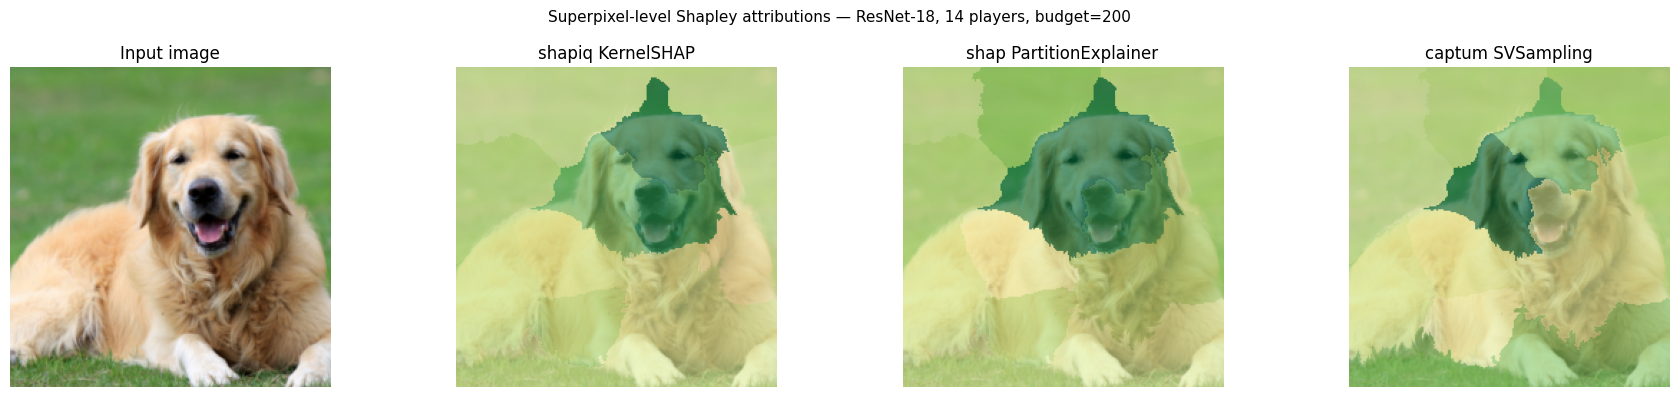

In [8]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import cm


def heatmap_sp(values, masks, img):
    h = np.zeros(img.shape[:2], dtype=float)
    for i, m in enumerate(masks):
        h[m.astype(bool)] = values[i]
    return h


fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Original image
axes[0].imshow(image_224)
axes[0].set_title("Input image")
axes[0].axis("off")

panels = [
    ("shapiq KernelSHAP", sv_shapiq),
    (
        "shap PartitionExplainer" if _has_shap else "SHAP (not installed)",
        sv_shap_agg if _has_shap else np.zeros(N_SEGS),
    ),
    (
        "captum SVSampling" if _has_captum else "captum (not installed)",
        sv_captum_agg if _has_captum else np.zeros(N_SEGS),
    ),
]

# Per-panel color scale: libraries report attributions on different scales (SHAP values
# are often orders of magnitude smaller than KernelSHAP on probabilities). Spearman ρ in
# Table = rankings. Heatmaps = per-library pattern (not raw magnitudes).
for ax, (title, sv) in zip(axes[1:], panels, strict=False):
    heat = heatmap_sp(sv, imputer_comp.player_masks, image_224)
    v = max(abs(heat.min()), abs(heat.max())) + 1e-9
    ax.imshow(image_224)
    ax.imshow(
        heat,
        cmap=cm.RdYlGn,
        norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v),
        alpha=0.6,
    )
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(
    f"Superpixel Shapley attributions (ResNet-18, {N_SEGS} players, budget={BUDGET_COMP})",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### 11.5  Summary table and discussion

In [9]:
import pandas as pd

rows = [
    {
        "Library": "shapiq (KernelSHAP)",
        "Time (s)": f"{t_shapiq:.2f}",
        "Wall-clock (relative)": "1.0×",
        "API lines": "~8",
        "Higher-order": "Yes (any order)",
        "Framework-agnostic": "Yes (any callable)",
        "Spearman ρ (vs. shapiq)": "n/a",
        "Model evals (approx.)": f"{shapiq_coalition_evals} coalitions / {shapiq_forward_batches} batches",
    },
    {
        "Library": "shap.PartitionExplainer",
        "Time (s)": f"{t_shap:.2f}" if _has_shap else "N/A",
        "Wall-clock (relative)": f"{t_shap / t_shapiq:.1f}×" if _has_shap else "N/A",
        "Model evals (approx.)": f"≤{shap_model_evals} (batched)" if _has_shap else "N/A",
        "API lines": "~10",
        "Higher-order": "No (first-order only)",
        "Framework-agnostic": "Yes",
        "Spearman ρ (vs. shapiq)": f"{rho_shap:+.3f}" if _has_shap else "N/A",
    },
    {
        "Library": "captum.ShapleyValueSampling",
        "Time (s)": f"{t_captum:.2f}" if _has_captum else "N/A",
        "Wall-clock (relative)": f"{t_captum / t_shapiq:.1f}×" if _has_captum else "N/A",
        "API lines": "~15",
        "Higher-order": "No (first-order only)",
        "Framework-agnostic": "PyTorch only",
        "Spearman ρ (vs. shapiq)": f"{rho_captum:+.3f}" if _has_captum else "N/A",
        "Model evals (approx.)": (f"{captum_forward_passes} sequential" if _has_captum else "N/A"),
    },
]

df_comp = pd.DataFrame(rows).set_index("Library")
print(df_comp.to_string())

                            Time (s) Wall-clock (relative) API lines           Higher-order  Framework-agnostic Spearman ρ (vs. shapiq)       Model evals (approx.)
Library                                                                                                                                                            
shapiq (KernelSHAP)             5.53                  1.0×        ~8        Yes (any order)  Yes (any callable)                       ( 200 coalitions / 7 batches
shap.PartitionExplainer         5.72                  1.0×       ~10  No (first-order only)                 Yes                  +0.437              ≤200 (batched)
captum.ShapleyValueSampling    79.46                 14.4×       ~15  No (first-order only)        PyTorch only                  +0.376              201 sequential


### Discussion

**Agreement.** Spearman $\rho$ is rank correlation on superpixel scores, not pixel-level heatmap overlap. **+0.4** (see table) is typical on this dog photo: all three libraries usually agree on the coarse region (face/body), but estimators, budget accounting, and baselines differ (mean-color vs. normalized zeros for captum). SHAP returns pixel attributions that we average onto the shapiq partition, which pulls $\rho$ down vs. a native superpixel game. $\rho \approx 0.4$ means same story, different numbers. Only $\rho$ well below zero would mean contradictory rankings.

**Runtime.** Timings use `time.perf_counter()` on the explain/attribute call only (setup excluded, one warm-up per library). All three target ~200 model evaluations on 14 superpixels. **shapiq batches** coalitions (~7 ResNet forwards of size 32). **captum runs ~201 sequential** forwards (`n_samples=200` permutations). So captum can be ~15× slower at the same budget. That is not a timing bug. Older notebook versions used `n_samples=14` (~15 forwards, ~6 s), which matched wall-clock but **under-sampled** captum (ρ often ~0.2). Runtime scales roughly linearly with sample budget. The exact ratio depends on:

- shapiq: batched forward pass, one model call per chunk.
- `shap.PartitionExplainer`: tree of coalition evaluations.
- `captum.ShapleyValueSampling`: permutation estimator, not batched.

For large budgets, shapiq batching wins (sections 4–5). Below ~100 coalitions the gap is small.

**Higher-order interactions.** Only shapiq ships k-SII, STII, FSII out of the box. SHAP and captum are first-order. Pairwise interactions need custom code elsewhere.

**API ergonomics.** shapiq needs a `callable` only. SHAP needs `maskers.Image`. captum needs `torch.nn.Module` plus a feature mask tensor.

**Recommendation.** For a quick first-order map on PyTorch, any library is fine. For higher-order interactions, JAX/Flax, or custom player sets beyond pixels, shapiq is the one that fits.
